In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Multivariable Calculus

A deep network's loss is a function of millions to billions of weights, yet
training rests on a single question asked over and over: how does the loss
change when we nudge the parameters? that section
answered this for one variable. This section lifts that local-linear picture to
many variables. The central object is the *gradient*, and we will see three
things about it that the rest of deep learning leans on: it is the multivariable
derivative (a first-order approximation), it points in the direction of steepest
change (which is why we descend along it), and organizing the chain rule around
it *is* the backpropagation algorithm. We close with the *Hessian*, the
second-order term that tells a minimum from a saddle.

## From Partial Derivatives to the Gradient

### Partial Derivatives

The one observation we already have is this: if we change a *single* weight
$w_1$ and freeze the rest, we are back to a function of one variable, and
that section applies verbatim:

$$L(w_1+\epsilon_1, w_2, \ldots, w_N) \approx L(w_1, w_2, \ldots, w_N) + \epsilon_1 \frac{\partial}{\partial w_1} L(w_1, w_2, \ldots, w_N).$$

The derivative in one variable *while holding the others fixed* is the *partial
derivative*, written $\frac{\partial}{\partial w_1}$. The new idea is what
happens when we perturb several coordinates at once.

### The Gradient

Suppose we perturb every coordinate, replacing each $w_i$ by $w_i + \epsilon_i$.
Apply the equation one coordinate at a time. Changing $w_1$
contributes $\epsilon_1\frac{\partial L}{\partial w_1}$; changing $w_2$
contributes $\epsilon_2\frac{\partial L}{\partial w_2}$, and so on. The
corrections that involve *two* perturbations, like
$\epsilon_1\epsilon_2\frac{\partial^2 L}{\partial w_1 \partial w_2}$, are
products of small quantities (second order), and we discard them exactly as we
discarded $\epsilon^2$ in one variable. What survives is a single sum:

$$
L(w_1+\epsilon_1, \ldots, w_N+\epsilon_N) \approx L(w_1, \ldots, w_N) + \sum_{i=1}^N \epsilon_i \frac{\partial L}{\partial w_i}.
$$

That sum on the right is a dot product. Collecting the perturbations and the
partials into vectors,

$$
\boldsymbol{\epsilon} = [\epsilon_1, \ldots, \epsilon_N]^\top
\quad\textrm{and}\quad
\nabla_{\mathbf{w}} L = \left[\frac{\partial L}{\partial w_1}, \ldots, \frac{\partial L}{\partial w_N}\right]^\top,
$$

we obtain the multivariable analogue of the linear approximation,

$$L(\mathbf{w} + \boldsymbol{\epsilon}) \approx L(\mathbf{w}) + \boldsymbol{\epsilon}\cdot \nabla_{\mathbf{w}} L(\mathbf{w}).$$

The vector $\nabla_{\mathbf{w}} L$ is the *gradient* of $L$. Equation
the equation has exactly the shape of the one-dimensional
$f(x+\epsilon) \approx f(x) + \epsilon f'(x)$, with the scalar derivative
replaced by the gradient and ordinary multiplication replaced by a dot product.
The gradient *is* the derivative in many dimensions: it is the unique vector
whose dot product with a perturbation gives the first-order change in $L$. We
treat $\nabla_{\mathbf{w}} L$ as a column vector throughout; the layout
conventions that make this choice precise are settled in
that section.

The coordinate-at-a-time argument tacitly assumed the partials behave well
*jointly*. The definition keeps the two ideas separate: $L$ is called
*differentiable* at $\mathbf{w}$ if the linear approximation
the equation holds with an error vanishing faster than
$\|\boldsymbol{\epsilon}\|$. A sufficient condition, and the one we rely on in
practice, is that the partials exist and are *continuous* near $\mathbf{w}$.
Existence of the $N$ partials alone is not enough: $f(x, y) = 2xy/(x^2+y^2)$ with
$f(0,0) = 0$ has both partials equal to zero at the origin, yet equals $1$
everywhere on the diagonal $x = y \neq 0$, so no linear approximation can hold
there. The losses in this book are built from pieces smooth enough that this
hypothesis costs nothing.

### Directional Derivatives

Reading the equation for a perturbation $\boldsymbol{\epsilon} =
h\,\mathbf{u}$ of size $h$ along a unit direction $\mathbf{u}$ shows what the
gradient says about *any* direction at once:

$$
\frac{L(\mathbf{w} + h\,\mathbf{u}) - L(\mathbf{w})}{h} \;\xrightarrow{\;h\to 0\;}\; \mathbf{u}\cdot\nabla_{\mathbf{w}} L(\mathbf{w}).
$$

The rate of change of $L$ as we move along $\mathbf{u}$, the *directional
derivative*, is the projection of the gradient onto $\mathbf{u}$. The single
vector $\nabla_{\mathbf{w}} L$ thus encodes the slope in every direction
simultaneously. The next section turns this one identity into the geometry of
gradient descent.

First, let us check that the equation really does approximate $L$.

In [1]:
%matplotlib inline
from d2l import jax as d2l
import jax
from jax import numpy as jnp
import math

Take

$$
f(x, y) = \log(e^x + e^y), \qquad \nabla f (x, y) = \left[\frac{e^x}{e^x+e^y}, \frac{e^y}{e^x+e^y}\right]^\top.
$$

At the point $(0, \log 2)$ we have $f = \log 3$ and $\nabla f = [\tfrac13, \tfrac23]^\top$,
so the equation predicts
$f(\epsilon_1, \log 2 + \epsilon_2) \approx \log 3 + \tfrac13\epsilon_1 + \tfrac23\epsilon_2$.
We compare this against the true value for a small step. The check is plain
scalar arithmetic.

In [2]:
def f(x, y):
    return math.log(math.exp(x) + math.exp(y))

def grad_f(x, y):
    s = math.exp(x) + math.exp(y)
    return [math.exp(x) / s, math.exp(y) / s]

epsilon = [0.01, -0.03]
x0, y0 = 0, math.log(2)
approx = f(x0, y0) + sum(e * g for e, g in zip(epsilon, grad_f(x0, y0)))
true_value = f(x0 + epsilon[0], y0 + epsilon[1])
print(f'approximation: {approx:.6f}, true value: {true_value:.6f}')

approximation: 1.081946, true value: 1.082124


The two agree to about three decimal places, with a gap of $1.8\times10^{-4}$.
The gap is not noise, and its size is itself a lesson: a first-order model
discards terms of order $\|\boldsymbol{\epsilon}\|^2$, and here
$\|\boldsymbol{\epsilon}\|^2 = 10^{-3}$: shrink the step tenfold and the gap
shrinks a hundredfold. The discarded term has a name and a formula (the Hessian
quadratic $\tfrac12\boldsymbol{\epsilon}^\top\mathbf{H}f\,\boldsymbol{\epsilon}$),
which we develop at the end of this section.

The same example models a workflow we will use constantly: whenever we derive a
gradient by hand, we check it against automatic differentiation. Here
autograd should reproduce $\nabla f(0, \log 2) = [\tfrac13, \tfrac23]^\top$.

In [3]:
# Check the hand-derived gradient at (0, log 2): [1/3, 2/3]
grad = jax.grad(jax.scipy.special.logsumexp)(jnp.array([0.0, math.log(2.0)]))
print(f'autograd gradient: {grad}')

autograd gradient: [0.33333334 0.6666667 ]


Up to display precision, the printout is our hand-computed
$[\tfrac13, \tfrac23]^\top$.

## The Geometry of Gradients

### Steepest Descent

Equation the equation tells us how $L$ changes in *any* direction,
so we can ask which direction makes it decrease fastest. This is the geometric
content of gradient descent, first introduced in that section:

1. Start from some initial parameters $\mathbf{w}$.
2. Find the unit direction $\mathbf{v}$ along which $L$ decreases most rapidly.
3. Take a small step that way: $\mathbf{w} \leftarrow \mathbf{w} + \eta\mathbf{v}$.
4. Repeat.

Everything hinges on step 2. Write the gradient's effect on a unit direction
$\mathbf{v}$ using the geometric form of the dot product from
that section,

$$
L(\mathbf{w} + \mathbf{v}) - L(\mathbf{w}) \approx \mathbf{v}\cdot \nabla_{\mathbf{w}} L(\mathbf{w}) = \|\nabla_{\mathbf{w}} L(\mathbf{w})\|\cos(\theta),
$$

where $\theta$ is the angle between $\mathbf{v}$ and the gradient. The direction
enters only through $\cos\theta$.

**Proposition (steepest ascent and descent).** *At any point where
$\nabla L \neq \mathbf{0}$, among all unit vectors $\mathbf{v}$ the directional
derivative $\mathbf{v}\cdot\nabla L$ is largest when $\mathbf{v}$ points along
$+\nabla L$ and smallest when it points along $-\nabla L$. Thus $+\nabla L$ is
the direction of steepest ascent and $-\nabla L$ the direction of steepest
descent.*

**Proof.** By Cauchy–Schwarz (the equation) applied to the
unit vector $\mathbf{v}$,

$$
-\|\nabla L\| \;\le\; \mathbf{v}\cdot\nabla L \;\le\; \|\nabla L\|,
$$

and the Cauchy–Schwarz equality criterion (equality holds exactly for
collinear vectors) says each bound is attained exactly
when $\mathbf{v}$ is collinear with $\nabla L$. The upper bound $+\|\nabla L\|$
is reached by $\mathbf{v} = \nabla L/\|\nabla L\|$ and the lower bound
$-\|\nabla L\|$ by $\mathbf{v} = -\nabla L/\|\nabla L\|$. $\blacksquare$

In the $\cos\theta$ picture this is simply $\theta = 0$ versus $\theta = \pi$.
Steepest descent therefore steps along $-\nabla_{\mathbf{w}} L$, and
the informal recipe becomes the gradient-descent update

$$
\mathbf{w} \leftarrow \mathbf{w} - \eta\,\nabla_{\mathbf{w}} L(\mathbf{w}).
$$

Every optimizer in this book, from momentum through RMSProp to Adam
(that section), modifies *how* the step along the gradient is
computed, but they all inherit this core idea: read the gradient, move against
it.

### Gradients and Level Sets

The same expression $L(\mathbf{w} + \mathbf{v}) - L(\mathbf{w}) \approx
\|\nabla L\|\cos\theta$ also reveals what the gradient is *geometrically*, not
just which way to step. Consider moving along a *level set*, the set of points
where $L$ keeps a fixed value $c$. To first order, $L$ does not change along
such a direction, so the directional derivative vanishes.

**Proposition (gradients are normal to level sets).** *At any point, $\nabla L$
is orthogonal to every direction tangent to the level set
$\{\mathbf{x} : L(\mathbf{x}) = c\}$ through that point.*

**Proof.** A direction $\mathbf{v}$ is *tangent* to the level set at
$\mathbf{x}$ if $\mathbf{v} = \boldsymbol{\gamma}'(0)$ for some differentiable
curve $\boldsymbol{\gamma}(t)$ lying in the level set with
$\boldsymbol{\gamma}(0) = \mathbf{x}$. Along such a curve
$L(\boldsymbol{\gamma}(t)) = c$ for all $t$, so the derivative of
$t \mapsto L(\boldsymbol{\gamma}(t))$ at $t = 0$ vanishes. To first order
$\boldsymbol{\gamma}(t) = \mathbf{x} + t\mathbf{v} + o(t)$, so by
the equation that derivative is $\mathbf{v}\cdot\nabla L(\mathbf{x})$.
Hence $\mathbf{v}\cdot\nabla L = 0$; by the definition of orthogonality from
that section, $\mathbf{v}\perp\nabla L$.
$\blacksquare$

So on a contour map the gradient is the arrow crossing the contours at right
angles, pointing toward higher ground, and it is longest where the contours
bunch together, exactly where $L$ changes fastest, as drawn in
the figure. Gradient descent slides *downhill across
the contours*, always perpendicular to them.

![Contours of a scalar field $L$ with its gradient $\nabla L$ drawn at several points: each arrow crosses the contours at a right angle, points toward higher values, and is longest where the contours bunch together, where $L$ changes fastest.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-gradient-field.svg)

### Tangent Planes and Linearization

The level-set picture lives in the *base plane*, where the gradient is the arrow
normal to the contours. There is a companion picture one dimension up, on the
*graph* $z = f(\mathbf{x})$ itself. Reading the equation as an
equation for the height $z$ rather than as an approximation gives the
*linearization* of $f$ at $\mathbf{x}_0$,

$$
z = f(\mathbf{x}_0) + \nabla f(\mathbf{x}_0)\cdot(\mathbf{x}-\mathbf{x}_0),
$$

a linear function of $\mathbf{x}$ whose graph is a plane (a hyperplane in higher
dimensions). It passes through the point $(\mathbf{x}_0, f(\mathbf{x}_0))$ and
matches every first-order slope of $f$ there, so it is the *tangent plane* to the
surface: the two-dimensional analogue of the tangent line, and the surface's
best linear approximation near $\mathbf{x}_0$.

Rewrite
the equation as $\nabla f(\mathbf{x}_0)\cdot(\mathbf{x}-\mathbf{x}_0) - (z - f(\mathbf{x}_0)) = 0$:
this says the augmented vector $[\nabla f(\mathbf{x}_0),\, -1]^\top$ is normal,
*in graph space*, to the tangent plane; the gradient is normal to the surface
once we account for the height direction. Drop the height coordinate, projecting
that normal straight down onto the base plane, and we recover $\nabla f$ crossing
the level curves at right angles. the figure shows both at
once: the tangent plane riding the surface, and the gradient's shadow meeting the
contours square on.

![A surface $z = f(\mathbf{x})$ with its tangent plane at a point, and the gradient $\nabla f$ projected onto the base plane, where it crosses the level curves of $f$ at right angles. The tangent plane is the graph-space view of the linearization; the perpendicular crossing is the base-plane view, two faces of the same first-order approximation.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-tangent-plane.svg)

### Critical Points and the First-Order Test

Throughout this book we minimize losses numerically, because the functions that
arise in deep learning are far too complex to minimize in closed form. But the
geometry above gives a cheap, exact *necessary* condition that every minimum
must satisfy.

Suppose someone hands us a point $\mathbf{x}_0$ and claims it minimizes $L$. Is
the claim even plausible? Read the equation at $\mathbf{x}_0$: if
$\nabla L(\mathbf{x}_0) \neq \mathbf{0}$, then stepping along
$-\nabla L(\mathbf{x}_0)$ strictly decreases $L$, so $\mathbf{x}_0$ cannot be a
minimum. Contrapositively, **a minimum forces $\nabla L(\mathbf{x}_0) =
\mathbf{0}$.** Points where the gradient vanishes are called *critical points*.

This is occasionally enough to optimize by hand. For example,

$$
f(x) = 3x^4 - 4x^3 - 12x^2, \qquad f'(x) = 12x(x-2)(x+1),
$$

has critical points $x = -1, 0, 2$ with values $-5, 0, -32$, so the minimum is
at $x = 2$, as the plot confirms.

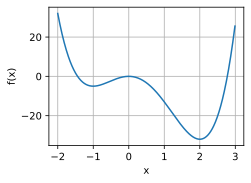

In [4]:
import numpy as onp
x = onp.arange(-2, 3, 0.01)
f = (3 * x**4) - (4 * x**3) - (12 * x**2)

d2l.plot(x, f, 'x', 'f(x)')

But not every critical point is an extremum: $x = 0$ above is a local maximum,
and in higher dimensions a critical point can be a saddle. Telling these apart
needs *second*-order information, the Hessian we develop below.

### Optimizing on a Constraint

The first-order test answers "where can an unconstrained minimum be?" One more
turn of the same geometry answers the constrained question that pervades machine
learning: minimize a loss *subject to* keeping some quantity fixed, say
$g(\mathbf{x}) = c$. Now we are no longer free to step in any direction: the
admissible moves are exactly those tangent to the constraint surface
$\{g = c\}$. At a constrained optimum $\mathbf{x}^\star$, *no* admissible
direction can lower $f$ to first order: otherwise we would slide along the
constraint and improve. By the equation that means
$\nabla f(\mathbf{x}^\star)$ has zero component along every direction tangent to
$\{g = c\}$; it is orthogonal to that surface. But we proved above that
$\nabla g$ is *also* orthogonal to $\{g = c\}$. One hypothesis makes the
geometry rigorous: provided $\nabla g(\mathbf{x}^\star) \neq \mathbf{0}$, the
standard *constraint qualification*, the implicit function theorem (stated in
that section; see [@Rudin.1976]) guarantees that
$\{g = c\}$ really is a smooth surface of codimension one near
$\mathbf{x}^\star$ (one equation removes one degree of freedom, leaving an
$(n{-}1)$-dimensional surface) with a single normal direction; it also supplies
the fact, used tacitly above, that every tangent direction is realized by a
curve lying in $\{g = c\}$, so "sliding along the constraint" is a legitimate
move. Two vectors normal to the same surface must be parallel, so at the
constrained optimum

$$
\nabla f(\mathbf{x}^\star) = \lambda\,\nabla g(\mathbf{x}^\star)
$$

for some scalar $\lambda$, the *Lagrange multiplier*. This single picture, the
contours of $f$ kissing the constraint surface where their gradients align
(the figure), is
the first-order condition for constrained optimization, the seed of the KKT
conditions and of duality. We meet it again in full force in
that section.

![Lagrange multipliers as tangency. At the constrained optimum the level set of $f$ is tangent to the constraint curve $g = c$ and the two gradients align, $\nabla f = \lambda \nabla g$. At a non-optimal feasible point the gradients disagree, so $\nabla f$ keeps a component along the constraint and sliding along it still improves $f$.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-lagrange-tangency.svg)

## The Multivariate Chain Rule

Neural networks are deep compositions of simple functions, so computing
gradients means differentiating compositions. Consider four inputs $w, x, y, z$
flowing through intermediate quantities to a scalar output:

$$\begin{aligned}f(u, v) & = (u+v)^{2} \\u(a, b) & = (a+b)^{2}, \qquad v(a, b) = (a-b)^{2}, \\a(w, x, y, z) & = (w+x+y+z)^{2}, \qquad b(w, x, y, z) = (w+x-y-z)^2.\end{aligned}$$

The dependencies form a graph (the figure): each node is a value,
each edge a direct functional dependence.

![The function relations of the equation, drawn as a graph where nodes are values and edges show direct functional dependence.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-chain-net1.svg)

We *could* substitute everything and differentiate the resulting monster
directly, but $\frac{\partial f}{\partial w}$ alone expands into a page of
repeated subexpressions, and $\frac{\partial f}{\partial x}$ would repeat most
of them again. That waste is precisely what the chain rule organizes away.

### The Rule as a Sum Over Paths

Take the simplest composite step, $f(u(a,b), v(a,b))$, and perturb $a$ by a
small $\epsilon$. Each intermediate moves by its partial,
$u \to u + \epsilon\frac{\partial u}{\partial a}$ and
$v \to v + \epsilon\frac{\partial v}{\partial a}$, and feeding those into the
first-order expansion of $f$ gives

$$
f\!\left(u + \epsilon\tfrac{\partial u}{\partial a},\, v + \epsilon\tfrac{\partial v}{\partial a}\right)
\approx f(u, v) + \epsilon\left[\frac{\partial f}{\partial u}\frac{\partial u}{\partial a} + \frac{\partial f}{\partial v}\frac{\partial v}{\partial a}\right].
$$

Reading off the coefficient of $\epsilon$ gives the multivariate chain rule,

$$
\frac{\partial f}{\partial a} = \frac{\partial f}{\partial u}\frac{\partial u}{\partial a} + \frac{\partial f}{\partial v}\frac{\partial v}{\partial a}.
$$

In words, there are two *pathways* by which $a$
influences $f$: $a \to u \to f$ and $a \to v \to f$. Each path contributes the
*product* of the derivatives along its edges, and the total derivative is the
*sum* over paths. This is the whole rule.

In general, to differentiate the output with respect to an input we **sum, over
every directed path from that input to the output, the product of the edge
derivatives along the path.**

To see the rule at work on a graph that is not a tree, consider a
*different* composition (its own dependency graph, unrelated to
the equation) in which one intermediate feeds the output both
directly and through a later node:

$$\begin{aligned}u(x, y) & = x + y, \qquad v(x, y) = x - y, \\a(u) & = u^2, \qquad b(v) = v^2, \\f(a, u, b) & = a + u + b.\end{aligned}$$

These relations are exactly the edges drawn in the figure:
$u$ and $v$ each depend on the input $y$; $a$ depends on $u$ and $b$ on $v$; and
the output $f$ depends on $a$, on $b$, and *also directly on $u$*: the skip-like
edge that gives the middle path below. Tracing every directed route from $y$ to
$f$ (namely $y\to u\to a\to f$, the direct $y\to u\to f$, and
$y\to v\to b\to f$), the rule gives

$$
\frac{\partial f}{\partial y} = \frac{\partial f}{\partial a} \frac{\partial a}{\partial u} \frac{\partial u}{\partial y} + \frac{\partial f}{\partial u} \frac{\partial u}{\partial y} + \frac{\partial f}{\partial b} \frac{\partial b}{\partial v} \frac{\partial v}{\partial y}.
$$

![A second, distinct dependency graph, the equation: the input $y$ reaches the output $f$ by three directed paths ($y\to u\to a\to f$, the direct skip $y\to u\to f$, and $y\to v\to b\to f$), and the chain rule sums their contributions.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-chain-net2.svg)

Here every edge derivative is elementary
($\partial f/\partial a = \partial f/\partial u = \partial f/\partial b = 1$,
$\partial a/\partial u = 2u$, $\partial u/\partial y = 1$, and so on), so the
sum-over-paths value is checkable by hand: it collapses to
$2u + 1 - 2v = 2(x+y) + 1 - 2(x-y) = 1 + 4y$. This "sum over paths" view is
exactly how gradients flow through a network, and
it explains why architectural choices that open or close paths, such as the
gates of an LSTM (that section) or the skip connections of a residual
block (that section), shape learning by controlling that gradient flow.

### The Backpropagation Algorithm

Return to the equation and ask for $\frac{\partial f}{\partial
w}$. Applying the chain rule the obvious way pushes $w$ forward through the
graph,

$$
\frac{\partial f}{\partial w} = \frac{\partial f}{\partial u}\frac{\partial u}{\partial w} + \frac{\partial f}{\partial v}\frac{\partial v}{\partial w}, \qquad
\frac{\partial u}{\partial w} = \frac{\partial u}{\partial a}\frac{\partial a}{\partial w}+\frac{\partial u}{\partial b}\frac{\partial b}{\partial w}, \quad \ldots
$$

and the single-step partials are all elementary,

$$
\begin{aligned}
\frac{\partial f}{\partial u} = 2(u+v), & \quad\frac{\partial f}{\partial v} = 2(u+v), \\
\frac{\partial u}{\partial a} = 2(a+b), & \quad\frac{\partial u}{\partial b} = 2(a+b), \\
\frac{\partial v}{\partial a} = 2(a-b), & \quad\frac{\partial v}{\partial b} = -2(a-b), \\
\frac{\partial a}{\partial w} = 2(w+x+y+z), & \quad\frac{\partial b}{\partial w} = 2(w+x-y-z).
\end{aligned}
$$

In code this is a tidy forward sweep through the graph.

In [5]:
# Compute the value of the function from inputs to outputs
w, x, y, z = 1, 1, -2, 1
a, b = (w + x + y + z)**2, (w + x - y - z)**2
u, v = (a + b)**2, (a - b)**2
f = (u + v)**2
print(f'f at {w}, {x}, {y}, {z} is {f}')

# Compute the single step partials
df_du, df_dv = 2*(u + v), 2*(u + v)
du_da, du_db, dv_da, dv_db = 2*(a + b), 2*(a + b), 2*(a - b), -2*(a - b)
da_dw, db_dw = 2*(w + x + y + z), 2*(w + x - y - z)

# Compute the final result from inputs to outputs
du_dw, dv_dw = du_da*da_dw + du_db*db_dw, dv_da*da_dw + dv_db*db_dw
df_dw = df_du*du_dw + df_dv*dv_dw
print(f'df/dw at {w}, {x}, {y}, {z} is {df_dw}')

f at 1, 1, -2, 1 is 26896
df/dw at 1, 1, -2, 1 is 73472


This computes one derivative, $\frac{\partial f}{\partial w}$. The trouble is
that it gives us *no head start* on $\frac{\partial f}{\partial x}$: by keeping
$\partial w$ in every denominator, we organized the work around "how $w$ affects
everything." But in deep learning we want the opposite: how *one* loss is
affected by *every* parameter. So we keep $\partial f$ in every *numerator*
instead, walking the graph from the output backward:

$$
\begin{aligned}
\frac{\partial f}{\partial a} & = \frac{\partial f}{\partial u}\frac{\partial u}{\partial a}+\frac{\partial f}{\partial v}\frac{\partial v}{\partial a}, \qquad
\frac{\partial f}{\partial b} = \frac{\partial f}{\partial u}\frac{\partial u}{\partial b}+\frac{\partial f}{\partial v}\frac{\partial v}{\partial b}, \\
\frac{\partial f}{\partial w} & = \frac{\partial f}{\partial a}\frac{\partial a}{\partial w} + \frac{\partial f}{\partial b}\frac{\partial b}{\partial w}, \qquad (\textrm{and likewise for } x, y, z).
\end{aligned}
$$

Computing $\frac{\partial f}{\partial u}, \frac{\partial f}{\partial v}$ once,
then $\frac{\partial f}{\partial a}, \frac{\partial f}{\partial b}$, then all
four input derivatives, *reuses* every intermediate. One backward sweep yields
the gradient with respect to all inputs at once.

In [6]:
# Compute the value of the function from inputs to outputs
w, x, y, z = 1, 1, -2, 1
a, b = (w + x + y + z)**2, (w + x - y - z)**2
u, v = (a + b)**2, (a - b)**2
f = (u + v)**2
print(f'f at {w}, {x}, {y}, {z} is {f}')

# Compute the derivative using the decomposition above
# First compute the single step partials
df_du, df_dv = 2*(u + v), 2*(u + v)
du_da, du_db, dv_da, dv_db = 2*(a + b), 2*(a + b), 2*(a - b), -2*(a - b)
da_dw, db_dw = 2*(w + x + y + z), 2*(w + x - y - z)
da_dx, db_dx = 2*(w + x + y + z), 2*(w + x - y - z)
da_dy, db_dy = 2*(w + x + y + z), -2*(w + x - y - z)
da_dz, db_dz = 2*(w + x + y + z), -2*(w + x - y - z)

# Now compute how f changes when we change any value from output to input
df_da, df_db = df_du*du_da + df_dv*dv_da, df_du*du_db + df_dv*dv_db
df_dw, df_dx = df_da*da_dw + df_db*db_dw, df_da*da_dx + df_db*db_dx
df_dy, df_dz = df_da*da_dy + df_db*db_dy, df_da*da_dz + df_db*db_dz

print(f'df/dw at {w}, {x}, {y}, {z} is {df_dw}')
print(f'df/dx at {w}, {x}, {y}, {z} is {df_dx}')
print(f'df/dy at {w}, {x}, {y}, {z} is {df_dy}')
print(f'df/dz at {w}, {x}, {y}, {z} is {df_dz}')

f at 1, 1, -2, 1 is 26896
df/dw at 1, 1, -2, 1 is 73472
df/dx at 1, 1, -2, 1 is 73472
df/dy at 1, 1, -2, 1 is -68224
df/dz at 1, 1, -2, 1 is -68224


Two sanity checks are visible in the printout. The derivatives with respect to
$w$ and $x$ agree, as do those with respect to $y$ and $z$, as they must,
since $f$ reaches its inputs only through the sums $w+x$ and $y+z$. And the two
pairs differ in both magnitude and sign, so the sweep is genuinely telling the
four paths through the graph apart.

Computing derivatives *from $f$ back toward the inputs*, rather than forward from
the inputs, is what gives the algorithm its name: *backpropagation*
[@Rumelhart.Hinton.Williams.ea.1988]. It is two
passes: a *forward pass* that evaluates the function and records the single-step
partials, and a *backward pass* that accumulates $\frac{\partial f}{\partial
\cdot}$ from output to input. This is exactly how the deep learning library
obtains the gradient of the loss with respect to *every* weight in a
single sweep, and it is what the one-line autograd call in the cell below runs
under the hood.

In [7]:
# Define the function to differentiate
def f_comp(w, x, y, z):
    a, b = (w + x + y + z)**2, (w + x - y - z)**2
    u, v = (a + b)**2, (a - b)**2
    return ((u + v)**2).squeeze()

w, x, y, z = jnp.array([1.]), jnp.array([1.]), jnp.array([-2.]), jnp.array([1.])

# Compute gradients with respect to all four arguments
grad_f = jax.grad(f_comp, argnums=(0, 1, 2, 3))
w_grad, x_grad, y_grad, z_grad = grad_f(w, x, y, z)

print(f'df/dw at {w}, {x}, {y}, {z} is {w_grad}')
print(f'df/dx at {w}, {x}, {y}, {z} is {x_grad}')
print(f'df/dy at {w}, {x}, {y}, {z} is {y_grad}')
print(f'df/dz at {w}, {x}, {y}, {z} is {z_grad}')

df/dw at [1.], [1.], [-2.], [1.] is [73472.]
df/dx at [1.], [1.], [-2.], [1.] is [73472.]
df/dy at [1.], [1.], [-2.], [1.] is [-68224.]
df/dz at [1.], [1.], [-2.], [1.] is [-68224.]


The library's answer matches our hand-computed backward pass. Why backprop is
reverse-mode automatic differentiation, a chain of vector–Jacobian products,
and when to prefer it over forward mode is the
subject of that section.

## Second-Order Structure: the Hessian

The gradient is a first-order, linear approximation; to know whether a critical
point is a minimum we need the *curvature*, which lives in the second
derivatives. A function of $n$ variables has $n^2$ second partials,

$$
\frac{\partial^2 f}{\partial x_i \partial x_j} = \frac{\partial}{\partial x_i}\left(\frac{\partial}{\partial x_j} f\right),
$$

collected into the *Hessian* matrix

$$\mathbf{H}_f = \begin{bmatrix} \frac{\partial^2 f}{\partial x_1 \partial x_1} & \cdots & \frac{\partial^2 f}{\partial x_1 \partial x_n} \\ \vdots & \ddots & \vdots \\ \frac{\partial^2 f}{\partial x_n \partial x_1} & \cdots & \frac{\partial^2 f}{\partial x_n \partial x_n} \\ \end{bmatrix}.$$

These $n^2$ entries are not independent: the Hessian is symmetric, a result
known as the Clairaut–Schwarz theorem [@Rudin.1976].

**Proposition (symmetry of the Hessian; Clairaut–Schwarz).** *If the mixed partials of
$f$ exist and are continuous, then for all $i, j$,*

$$
\frac{\partial^2 f}{\partial x_i \partial x_j} = \frac{\partial^2 f}{\partial x_j \partial x_i},
\qquad\textrm{equivalently}\qquad \mathbf{H}_f = \mathbf{H}_f^\top.
$$

**Proof.** Both mixed partials are limits of the *same* quantity, the
symmetric second difference

$$
\Delta_h = \frac{f(\mathbf{x}+h\mathbf{e}_i+h\mathbf{e}_j) - f(\mathbf{x}+h\mathbf{e}_i) - f(\mathbf{x}+h\mathbf{e}_j) + f(\mathbf{x})}{h^2},
$$

which is symmetric in $i$ and $j$ by inspection. Indeed, write
$g(t) = f(\mathbf{x}+t\mathbf{e}_i+h\mathbf{e}_j) - f(\mathbf{x}+t\mathbf{e}_i)$,
so that $\Delta_h = \bigl(g(h)-g(0)\bigr)/h^2$; two applications of the mean
value theorem (first along $x_i$, then along $x_j$) give
$\Delta_h = \frac{\partial^2 f}{\partial x_j \partial x_i}(\boldsymbol{\xi}_h)$
at some point $\boldsymbol{\xi}_h$ within distance $2h$ of $\mathbf{x}$.
Swapping the roles of $i$ and $j$ leaves $\Delta_h$ unchanged and gives
$\Delta_h = \frac{\partial^2 f}{\partial x_i \partial x_j}(\boldsymbol{\xi}'_h)$
at another nearby point. Let $h \to 0$: by continuity the two expressions
converge to the two mixed partials at $\mathbf{x}$, and since they are equal
for every $h$, the limits agree. $\blacksquare$

Symmetry matters because it puts the Hessian in the world of symmetric matrices,
where the spectral theorem and positive-definiteness from
that section apply, which is exactly what the
second-derivative test will use.

### The Second-Order Taylor Approximation

Just as the gradient gives the best linear fit, the Hessian gives the best
*quadratic* fit. To see how the coefficients enter, read them off an exact
quadratic. Let $f(x_1, x_2) = a + b_1x_1 + b_2x_2 + c_{11}x_1^{2} + c_{12}x_1x_2 + c_{22}x_2^{2}$.
Evaluating the value, gradient, and Hessian the equation at the
origin gives

$$
f(0,0) = a, \qquad
\nabla f (0,0) = \begin{bmatrix}b_1 \\ b_2\end{bmatrix}, \qquad
\mathbf{H} f (0,0) = \begin{bmatrix}2 c_{11} & c_{12} \\ c_{12} & 2c_{22}\end{bmatrix},
$$

and these recover the polynomial exactly:
$f(\mathbf{x}) = f(0) + \nabla f(0) \cdot \mathbf{x} + \tfrac12\mathbf{x}^\top \mathbf{H} f(0)\, \mathbf{x}$.

For a general $f$, twice differentiable near a base point $\mathbf{x}_0$, the
same assembly is no longer exact, but restricting $f$ to a line shows exactly
how close it comes. Fix a displacement $\boldsymbol{\delta} = \mathbf{x} -
\mathbf{x}_0$ and let $g(t) = f(\mathbf{x}_0 + t\boldsymbol{\delta})$, a
function of the single variable $t$. By the multivariate chain rule,
$g'(t) = \nabla f(\mathbf{x}_0 + t\boldsymbol{\delta})\cdot\boldsymbol{\delta}$
and $g''(t) = \boldsymbol{\delta}^\top \mathbf{H} f(\mathbf{x}_0 +
t\boldsymbol{\delta})\,\boldsymbol{\delta}$, so $g'(0)$ and $g''(0)$ are
exactly the gradient term and the Hessian quadratic form at $\mathbf{x}_0$.
Now apply the single-variable Lagrange remainder the equation,
established in the previous section, to $g$ on $[0, 1]$ with $n = 1$: there is
a $\tau \in (0, 1)$ with

$$
f(\mathbf{x}) = g(1) = g(0) + g'(0) + \tfrac{1}{2}g''(\tau) = f(\mathbf{x}_0) + \nabla f(\mathbf{x}_0)\cdot\boldsymbol{\delta} + \tfrac{1}{2}\boldsymbol{\delta}^\top \mathbf{H} f(\mathbf{x}_0 + \tau\boldsymbol{\delta})\,\boldsymbol{\delta}.
$$

This identity is exact; its only blemish is that the Hessian is evaluated at
an intermediate point $\mathbf{x}_0 + \tau\boldsymbol{\delta}$ rather than at
$\mathbf{x}_0$. When the second partials are continuous, moving the evaluation
point back to $\mathbf{x}_0$ changes the quadratic term by
$o(\|\boldsymbol{\delta}\|^2)$, giving the *second-order Taylor approximation*

$$
f(\mathbf{x}) \approx f(\mathbf{x}_0) + \nabla f (\mathbf{x}_0) \cdot (\mathbf{x}-\mathbf{x}_0) + \frac{1}{2}(\mathbf{x}-\mathbf{x}_0)^\top \mathbf{H} f (\mathbf{x}_0) (\mathbf{x}-\mathbf{x}_0).
$$

This is the best-approximating quadratic to $f$ near $\mathbf{x}_0$ in a
precise sense: its error vanishes faster than $\|\mathbf{x}-\mathbf{x}_0\|^2$,
and it is the only quadratic with that property. For smoother $f$ (three
continuous derivatives) the error is *third order* in the step. To see it in
numbers, take $f(x, y) = xe^{-x^2-y^2}$. Assembling its value,
gradient, and Hessian at $\mathbf{x}_0 = [-1, 0]^\top$ via
the equation gives the approximating quadratic
$q(x, y) = e^{-1}\bigl(-1 - (x+1) + (x+1)^2 + y^2\bigr)$.
the figure plots the surface against this quadratic;
near $[-1, 0]^\top$ they hug each other and peel apart only as we move away.

![The surface $z = xe^{-x^2-y^2}$ (blue) and its second-order Taylor quadratic at the base point $(-1, 0)^\top$ (orange). The two agree in value, slope, and curvature there, so they are nearly indistinguishable in a neighborhood of the base point and separate only farther out.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-taylor-quadratic.svg)

The figure asserts agreement; we can check it numerically, exactly as
we checked the gradient above. Evaluating $f$ and its quadratic $q$ at a few
points stepping away from the base point, the gap should stay tiny nearby and
grow with distance.

In [8]:
def f(x, y):
    return x * math.exp(-x**2 - y**2)

def quad(x, y):  # 2nd-order Taylor of f at the base point (-1, 0)
    return math.exp(-1) * (-1 - (x + 1) + (x + 1)**2 + y**2)

for d in [0.0, 0.05, 0.1, 0.3]:  # step d in each coordinate from (-1, 0)
    x, y = -1 + d, d
    print(f'step {d:.2f}: f = {f(x, y):.6f}, '
          f'quadratic = {quad(x, y):.6f}, gap = {abs(f(x, y) - quad(x, y)):.6f}')

step 0.00: f = -0.367879, quadratic = -0.367879, gap = 0.000000
step 0.05: f = -0.384315, quadratic = -0.384434, gap = 0.000119
step 0.10: f = -0.396388, quadratic = -0.397310, gap = 0.000921
step 0.30: f = -0.391929, quadratic = -0.412025, gap = 0.020096


The gap vanishes at the base point and is third order in the step (doubling the
step roughly multiplies it by eight), the third-order behavior promised above.
Iterating this idea, repeatedly fitting the local quadratic and jumping to *its*
minimum, is Newton's method, which that section introduced in one
variable; that section develops it as a practical optimizer.

### The Second-Derivative Test

We can now finish the story the first-order test left open: at a critical point,
the Hessian decides whether we sit at a minimum, a maximum, or a saddle. At a
critical point $\mathbf{x}_0$ the gradient term in the equation
vanishes, so the local picture is purely quadratic,

$$
f(\mathbf{x}) - f(\mathbf{x}_0) \approx \frac{1}{2}(\mathbf{x}-\mathbf{x}_0)^\top \mathbf{H} f (\mathbf{x}_0)(\mathbf{x}-\mathbf{x}_0).
$$

Stepping a unit direction $\mathbf{v}$ away from $\mathbf{x}_0$ makes the
right-hand side $\tfrac12\mathbf{v}^\top\mathbf{H}\mathbf{v}$: the scalar
$\mathbf{v}^\top\mathbf{H}\mathbf{v}$ is the *second directional derivative* of
$f$ along $\mathbf{v}$, the second-order analogue of $\mathbf{v}\cdot\nabla f$,
and at a critical point, where the slope term is gone, it is the curvature of
$f$ along $\mathbf{v}$. Whether $f$ goes up or down as we leave $\mathbf{x}_0$
is governed entirely by the sign of this quadratic form, that is, by the
*definiteness* of the symmetric matrix $\mathbf{H}$. The classification is read straight off the
eigenvalues of $\mathbf{H}$ via the PSD/PD criterion of
that section:

* $\mathbf{H} \succ 0$ (all eigenvalues positive): $f$ curves *upward* in every
  direction. Quantitatively, the quadratic term is at least
  $\tfrac12\lambda_{\min}\|\mathbf{v}\|^2$ for a step $\mathbf{v}$, where
  $\lambda_{\min} > 0$ is the smallest eigenvalue, and this dominates the
  approximation's $o(\|\mathbf{v}\|^2)$ error for all small $\mathbf{v}$, so
  $\mathbf{x}_0$ is a strict local **minimum**.
* $\mathbf{H} \prec 0$ (all eigenvalues negative): $f$ curves downward
  everywhere, so $\mathbf{x}_0$ is a local **maximum**.
* $\mathbf{H}$ *indefinite* (eigenvalues of both signs): $f$ rises along some
  directions and falls along others: a **saddle**.
* $\mathbf{H} \succeq 0$ with a zero eigenvalue (semidefinite): the quadratic is
  flat along that eigenvector and second order is *inconclusive*; the behavior
  is decided by higher-order terms.

These local shapes (the bowl, the saddle, and the flat-bottomed trough of the
semidefinite case) are exactly the quadratic-form surfaces drawn in
the figure.

This is the multivariable generalization of the single-variable test $f'' > 0$:
there, curvature is a single number; here it is a matrix, and "positive
curvature" becomes "positive definite." Identity the equation makes
the upward-curving picture precise, writing the quadratic form as a weighted sum
of squares over the eigenvector directions with the eigenvalues as weights.

The test is one we can run. The surface of the figure,
$f(x, y) = xe^{-x^2-y^2}$, has exactly two critical points: setting
$\frac{\partial f}{\partial x} = (1 - 2x^2)\,e^{-x^2-y^2}$ and
$\frac{\partial f}{\partial y} = -2xy\,e^{-x^2-y^2}$ to zero forces $y = 0$ and
$x = \pm 1/\sqrt{2}$. The next cell assembles each Hessian from symmetric second
differences (the same quantity $\Delta_h$ that proved the Clairaut–Schwarz
theorem), reads
off the eigenvalues of a $2 \times 2$ symmetric matrix in closed form, and
prints the classification.

In [9]:
# Classify the critical points (+-1/sqrt(2), 0) of f(x, y) = x e^(-x^2-y^2)
def hessian(f, x, y, h=1e-4):  # symmetric second differences
    fxx = (f(x + h, y) - 2 * f(x, y) + f(x - h, y)) / h**2
    fyy = (f(x, y + h) - 2 * f(x, y) + f(x, y - h)) / h**2
    fxy = (f(x + h, y + h) - f(x + h, y - h)
           - f(x - h, y + h) + f(x - h, y - h)) / (4 * h**2)
    return fxx, fxy, fyy

for x0 in [-1 / math.sqrt(2), 1 / math.sqrt(2)]:
    fxx, fxy, fyy = hessian(f, x0, 0.0)
    mid, r = (fxx + fyy) / 2, math.sqrt(((fxx - fyy) / 2)**2 + fxy**2)
    lo, hi = mid - r, mid + r  # eigenvalues of [[fxx, fxy], [fxy, fyy]]
    kind = 'minimum' if lo > 0 else 'maximum' if hi < 0 else 'saddle'
    print(f'at ({x0:+.4f}, 0): eigenvalues {lo:+.3f}, {hi:+.3f} -> {kind}')

at (-0.7071, 0): eigenvalues +0.858, +1.716 -> minimum
at (+0.7071, 0): eigenvalues -1.716, -0.858 -> maximum


At $(-1/\sqrt{2}, 0)$ both eigenvalues are positive ($\mathbf{H} \succ 0$, a
strict local minimum) and at $(+1/\sqrt{2}, 0)$ both are negative, a local
maximum; a saddle would show one eigenvalue of each sign, as in
Exercise 5. This five-line loop is the second-derivative test as a program:
differentiate twice (here numerically; autograd Hessians appear in
that section), extract eigenvalues, read the signs.

The eigenvalue picture also explains why, in high dimension, saddles are the
rule rather than the exception: a minimum requires *all* $n$ eigenvalues to be
positive at once, and if the signs at a random critical point behaved like
independent coin flips, that would happen with probability $2^{-n}$. The
coin-flip heuristic can be made precise: for random Gaussian landscapes the
statistics of critical points can be computed exactly and minima are
exponentially outnumbered by saddles [@Bray.Dean.2007], and the critical
points actually encountered while training deep networks are overwhelmingly
saddles too [@Dauphin.Pascanu.Gulcehre.ea.2014], one reason gradient
methods fare better in practice than the old fear of "getting stuck in a bad
local minimum" suggests.

With the Hessian in hand, the one-variable toolkit has been fully lifted:
gradient for slope, Hessian for curvature, and the chain rule organized
backward for the computation. What has *not* yet been lifted is the function
itself: everything above differentiated a *scalar* loss, while real layers map
vectors to vectors and carry matrix parameters, so the derivative becomes a
matrix of partials, the *Jacobian*, with the gradient and Hessian as special
cases. One caution for that road: the Mean Value Theorem of
that section does *not* survive the passage to vector-valued maps;
only an inequality remains, the mean value inequality [@Rudin.1976]. The
Jacobian machinery, the layout conventions, and how it all yields
backpropagation as reverse-mode automatic differentiation are the subject of
that section.

## Summary

* The *gradient* $\nabla_{\mathbf{w}} L$ is the derivative in many dimensions: it
  gives the first-order change $L(\mathbf{w}+\boldsymbol{\epsilon}) \approx
  L(\mathbf{w}) + \boldsymbol{\epsilon}\cdot\nabla_{\mathbf{w}} L$, and its dot
  product with a unit direction is the rate of change along that direction.
* By Cauchy–Schwarz, $+\nabla L$ is the direction of steepest ascent and
  $-\nabla L$ of steepest descent, and the gradient is everywhere orthogonal to
  the level sets of $L$: the geometry behind gradient descent.
* The multivariate *chain rule* sums, over every path from an input to the
  output, the product of edge derivatives. Organizing it from the output
  backward reuses every intermediate, giving *backpropagation*: a forward pass
  followed by a backward pass that yields the gradient with respect to all
  parameters at once.
* The symmetric *Hessian* supplies the second-order Taylor approximation; at a
  critical point its definiteness, read from its eigenvalues, distinguishes a
  minimum, a maximum, and a saddle.

## Exercises
1. Let $L(x, y) = \log(e^x + e^y)$. Compute the gradient, and verify that the
   sum of its components is always $1$. What does that say about the directions
   in which $L$ grows fastest?
2. For $f(x, y) = x^2 + 2y^2$, compute $\nabla f$ and verify at a sample point on
   the ellipse $f = c$ that the gradient is orthogonal to the level curve.
3. Prove directly from the equation that at a local minimum the
   gradient must vanish.
4. Let $f(x, y) = x^3 - 3x + y^2$. Show that the critical points are
   $(\pm 1, 0)$. By examining $f$ along the lines $y = 0$ and $x = \pm 1$,
   determine whether each is a minimum, a maximum, or a saddle, and confirm by
   computing the Hessian there.
5. Classify the critical point of $f(x, y) = x^2 - y^2$ by inspecting the
   eigenvalues of its (constant) Hessian. Why is this point a saddle?
6. Give a two-variable $f$ whose Hessian at a critical point is positive
   *semidefinite* (one zero eigenvalue) yet the point is not a local minimum.
   Why does the second-derivative test go silent here?
7. Suppose we minimize $f(\mathbf{x}) = g(\mathbf{x}) + h(\mathbf{x})$. Interpret
   the condition $\nabla f = \mathbf{0}$ geometrically in terms of $\nabla g$ and
   $\nabla h$.
8. Use the Lagrange condition the equation to maximize
   $f(x, y) = xy$ subject to $g(x, y) = x + y = 1$. First check that
   $\nabla g \neq \mathbf{0}$ everywhere, so the condition applies; then solve
   $\nabla f = \lambda \nabla g$ together with the constraint, and confirm your
   answer by eliminating $y = 1 - x$ and maximizing in one variable. Finally,
   replace the constraint by $x + y = 1 + \delta$ and show that the maximum
   value changes by $\lambda\delta$ to first order: the multiplier prices the
   constraint.

[Discussions](https://d2l.discourse.group/t/1091)